# Explicabilité du modèle avec SHAP

## Contexte
Ce notebook explique les prédictions du modèle XGBoost entraîné 
sur le dataset AI4I 2020 Predictive Maintenance.

## Qu'est-ce que SHAP ?
SHAP (SHapley Additive exPlanations) est une méthode d'explicabilité 
basée sur la théorie des jeux. Elle répond à la question :

> *"Pourquoi mon modèle a-t-il prédit CETTE valeur pour CETTE machine ?"*

Chaque feature reçoit une valeur SHAP qui représente sa contribution 
à la prédiction finale, en positif ou en négatif.

## Comment lire les graphiques SHAP ?

### Beeswarm plot (vue globale)
- Chaque point = une machine du dataset
- Position horizontale = impact sur la prédiction de panne
- Couleur rouge = valeur élevée de la feature
- Couleur bleue = valeur faible de la feature
- Plus un point est à droite → plus il pousse vers la panne

### Waterfall plot (vue individuelle)
- Montre pourquoi UNE machine spécifique a été classée en panne
- Chaque barre = contribution d'une feature
- Barre rouge = pousse vers la panne (+)
- Barre bleue = réduit le risque de panne (-)

## Résultats clés
| Feature | Importance | Interprétation |
|---|---|---|
| Torque_Nm | 1ère | Couple élevé = risque critique |
| Tool_wear_min | 2ème | Usure avancée = signal d'alerte |
| Rotational_speed_rpm | 3ème | Vitesse faible = risque accru |
| Air_temperature_K | 4ème | Impact modéré |
| Process_temperature_K | 5ème | Faible impact direct |
| Type_encoded | 6ème | Type machine peu discriminant |

## Stack utilisé
- `shap==0.43.0` — librairie d'explicabilité
- `TreeExplainer` — optimisé pour XGBoost et Random Forest
- `joblib` — chargement du modèle pré-entraîné

In [1]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Imports et chargement du modèle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.preprocessing import LabelEncoder

# Chargement du modèle et des données
xgb = joblib.load(r'C:\Users\hp\predictive-maintenance-ml-datascience-project\models\xgb_model.pkl')
df = pd.read_csv(r'C:\Users\hp\predictive-maintenance-ml-datascience-project\data\ai4i2020.csv')

# Reproduire le même preprocessing
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

# Aligner les noms de colonnes avec ceux utilisés à l'entraînement
df = df.rename(columns={
    'Air temperature [K]': 'Air_temperature_K',
    'Process temperature [K]': 'Process_temperature_K',
    'Rotational speed [rpm]': 'Rotational_speed_rpm',
    'Torque [Nm]': 'Torque_Nm',
    'Tool wear [min]': 'Tool_wear_min'
})

features = [
    'Air_temperature_K',
    'Process_temperature_K',
    'Rotational_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min',
    'Type_encoded'
]

X = df[features]
y = df['Machine failure']

print("Modèle et données chargés avec succès")
print(f"Shape X : {X.shape}")

c:\Users\hp\predictive-maintenance-ml-datascience-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modèle et données chargés avec succès
Shape X : (10000, 6)


#  l'explainer SHAP

In [3]:

# Initialiser l'explainer SHAP pour XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X)

print(f"Shape shap_values : {shap_values.shape}")
print("Explainer SHAP créé avec succès")

Shape shap_values : (10000, 6)
Explainer SHAP créé avec succès


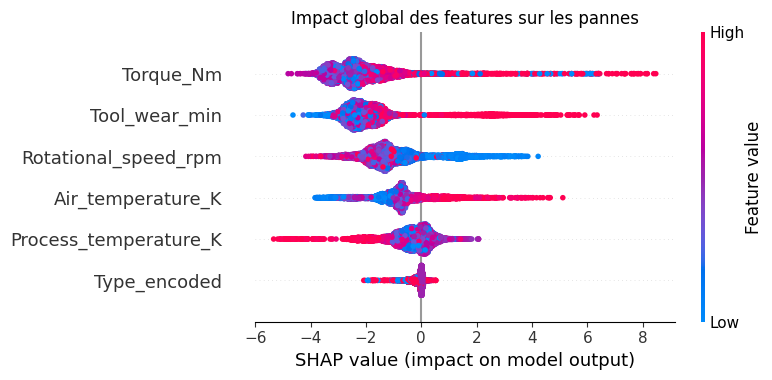

In [4]:
# Créer l'objet Explanation pour un meilleur affichage
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X.values,
    feature_names=features
)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(explanation, show=False, max_display=6)
plt.title('Impact global des features sur les pannes')
plt.tight_layout()
plt.savefig('../data/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

Chaque point = une machine. La couleur = valeur de la feature (rouge = élevée, bleu = faible). La position horizontale = impact sur la prédiction de panne.

Interprétation feature par feature

Torque_Nm — feature la plus importante. Les points rouges (couple élevé) sont très à droite → un couple élevé pousse fortement vers la panne. Les points bleus (couple faible) sont à gauche → protège contre la panne.

Tool_wear_min — deuxième feature. Les points rouges (usure élevée) à droite → plus l'outil est usé, plus le risque augmente. Confirme l'intuition physique.

Rotational_speed_rpm — les points bleus (vitesse faible) sont à droite → une vitesse basse augmente le risque. Cohérent avec la corrélation négative qu'on avait vue dans l'EDA (-0.88 avec Torque).

Air_temperature_K — impact modéré, les températures élevées augmentent légèrement le risque.

Process_temperature_K et Type_encoded — faible impact global.

# Waterfall plot (prédiction individuelle)

Machine analysée : index 50
État réel : PANNE

Valeurs des features :
  Air_temperature_K                   : 298.90
  Process_temperature_K               : 309.10
  Rotational_speed_rpm                : 2861.00
  Torque_Nm                           : 4.60
  Tool_wear_min                       : 143.00
  Type_encoded                        : 1.00


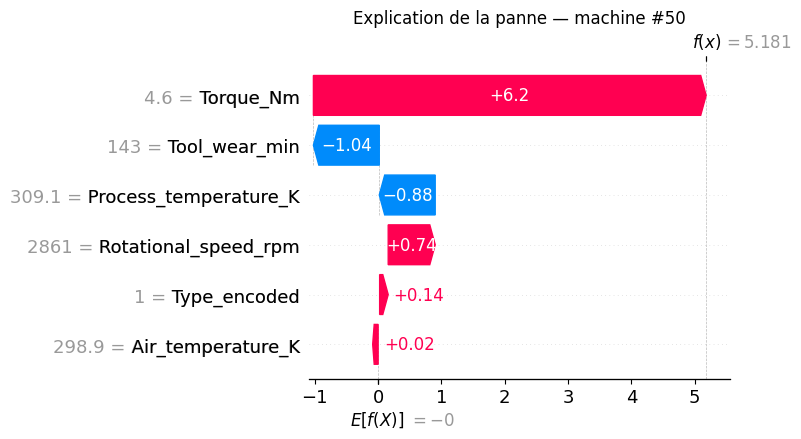

In [5]:
# Trouver une vraie panne dans le dataset
panne_indices = df[df['Machine failure'] == 1].index.tolist()
idx = panne_indices[0]

print(f"Machine analysée : index {idx}")
print(f"État réel : {'PANNE' if y[idx] == 1 else 'Normal'}")
print(f"\nValeurs des features :")
for f, v in zip(features, X.iloc[idx]):
    print(f"  {f:35s} : {v:.2f}")

# Waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx].values,
        feature_names=features
    ),
    show=False
)
plt.title(f'Explication de la panne — machine #{idx}')
plt.tight_layout()
plt.savefig('../data/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

Lecture du waterfall plot — machine #50

La valeur finale f(x) = 5.181 → score de panne très élevé, le modèle est très confiant.

Feature par feature :

Torque_Nm = 4.6 → +6.2 — c'est le facteur dominant. Un couple de 4.6 Nm pousse massivement vers la panne. C'est anormalement bas pour cette machine — signe d'un problème mécanique.

Rotational_speed_rpm = 2861 → +0.74 — vitesse élevée qui amplifie le risque, cohérent avec la corrélation négative vue en EDA.

Tool_wear_min = 143 → -1.04 — l'usure est modérée ici, elle réduit légèrement le score de risque.

Process_temperature_K = 309.1 → -0.88 — température de process normale, effet protecteur.

# Sauvegarder l'explainer

In [6]:
# Sauvegarder l'explainer pour le dashboard Streamlit
joblib.dump(explainer, '../models/shap_explainer.pkl')
joblib.dump(shap_values, '../models/shap_values.pkl')

print("Explainer SHAP sauvegardé dans /models/")
print("  - shap_explainer.pkl")
print("  - shap_values.pkl")

Explainer SHAP sauvegardé dans /models/
  - shap_explainer.pkl
  - shap_values.pkl


# Résumé SHAP

In [7]:
print("=" * 55)
print("RÉSUMÉ SHAP — INSIGHTS CLÉS")
print("=" * 55)
print("\n Top features par importance SHAP :")
print("  1. Torque_Nm          → feature dominante")
print("  2. Tool_wear_min      → deuxième signal")
print("  3. Rotational_speed   → corrélé au couple")
print("  4. Air_temperature    → impact modéré")
print("\n Interprétation métier :")
print("  Un couple élevé + usure avancée = risque critique")
print("  Ces deux features suffisent à expliquer")
print("  la majorité des pannes du dataset")
print("=" * 55)

RÉSUMÉ SHAP — INSIGHTS CLÉS

 Top features par importance SHAP :
  1. Torque_Nm          → feature dominante
  2. Tool_wear_min      → deuxième signal
  3. Rotational_speed   → corrélé au couple
  4. Air_temperature    → impact modéré

 Interprétation métier :
  Un couple élevé + usure avancée = risque critique
  Ces deux features suffisent à expliquer
  la majorité des pannes du dataset
